# EDA — Credit Card Fraud Detection

Dataset: [Kaggle mlg-ulb/creditcardfraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).
Run `scripts/download_data.sh` first so `data/creditcard.csv` exists.

Goals: understand class imbalance, `Amount`/`Time` behavior by class, and
whether the anonymized `V1`-`V28` features separate fraud from non-fraud.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/creditcard.csv")
df.shape

(284807, 31)

In [3]:
df.info()
df.isna().sum().sum()  # expect 0 missing values

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

np.int64(0)

## Class balance

Fraud (`Class == 1`) should be roughly 0.17% of transactions. This single
fact drives every modeling decision later: accuracy is meaningless here.

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


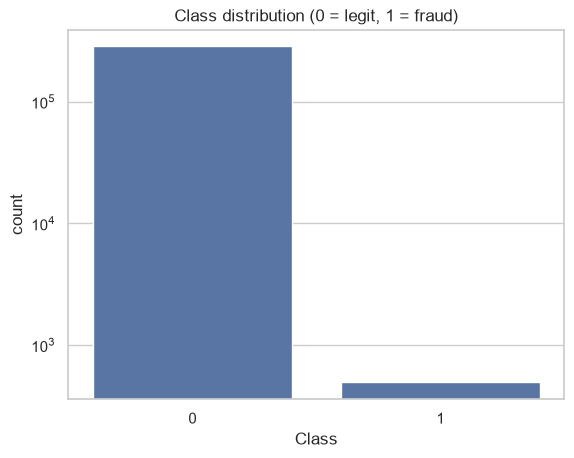

In [4]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct)

sns.countplot(x="Class", data=df)
plt.title("Class distribution (0 = legit, 1 = fraud)")
plt.yscale("log")
plt.show()

## Amount & Time by class

In [5]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


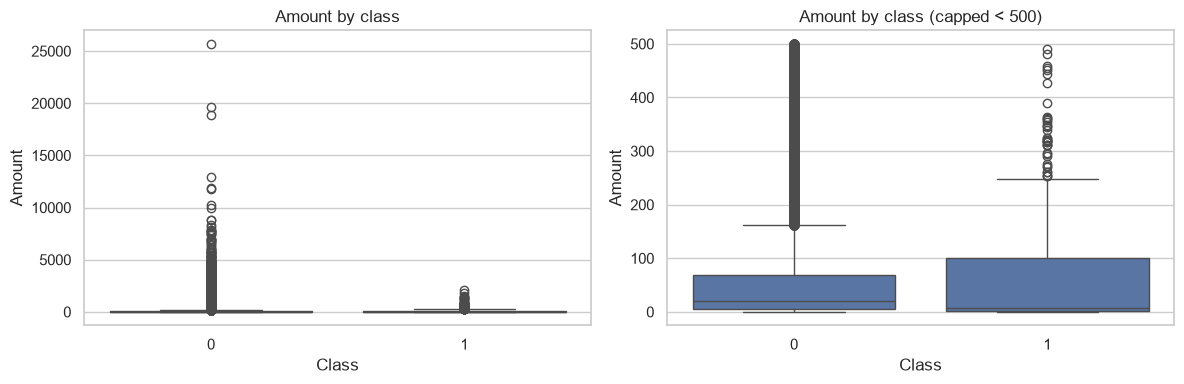

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x="Class", y="Amount", data=df, ax=axes[0])
axes[0].set_title("Amount by class")

sns.boxplot(x="Class", y="Amount", data=df[df["Amount"] < 500], ax=axes[1])
axes[1].set_title("Amount by class (capped < 500)")
plt.tight_layout()
plt.show()

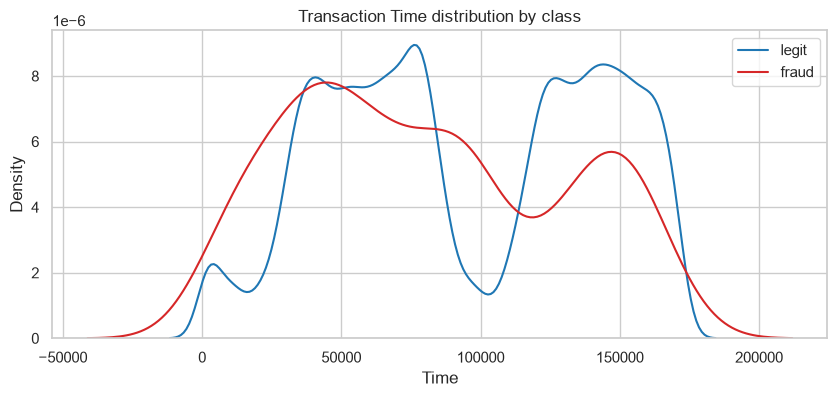

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
for cls, label, color in [(0, "legit", "tab:blue"), (1, "fraud", "tab:red")]:
    sns.kdeplot(df.loc[df["Class"] == cls, "Time"], label=label, color=color, ax=ax)
ax.set_title("Transaction Time distribution by class")
ax.legend()
plt.show()

## V1-V28 feature behavior

These are PCA-anonymized and not individually interpretable, but we can
still check which ones separate the classes best — useful for modeling
and later explainability (e.g. SHAP will cite these by name, not meaning).

In [8]:
v_cols = [c for c in df.columns if c.startswith("V")]

corr_with_class = df[v_cols + ["Class"]].corr()["Class"].drop("Class").sort_values()
corr_with_class

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
V5    -0.094974
V6    -0.043643
V24   -0.007221
V13   -0.004570
V15   -0.004223
V23   -0.002685
V22    0.000805
V25    0.003308
V26    0.004455
V28    0.009536
V27    0.017580
V8     0.019875
V20    0.020090
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

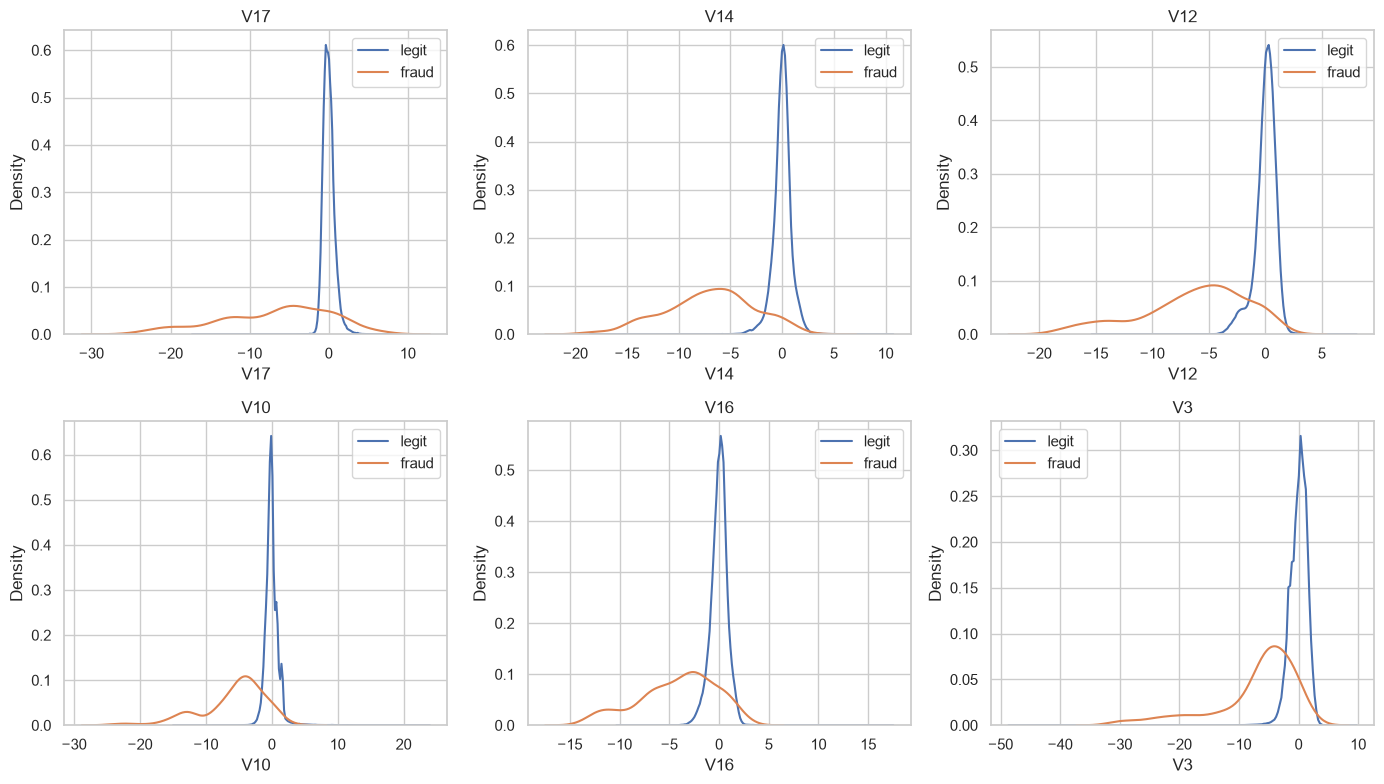

In [9]:
top_features = corr_with_class.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), top_features):
    sns.kdeplot(df.loc[df["Class"] == 0, col], label="legit", ax=ax)
    sns.kdeplot(df.loc[df["Class"] == 1, col], label="fraud", ax=ax)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

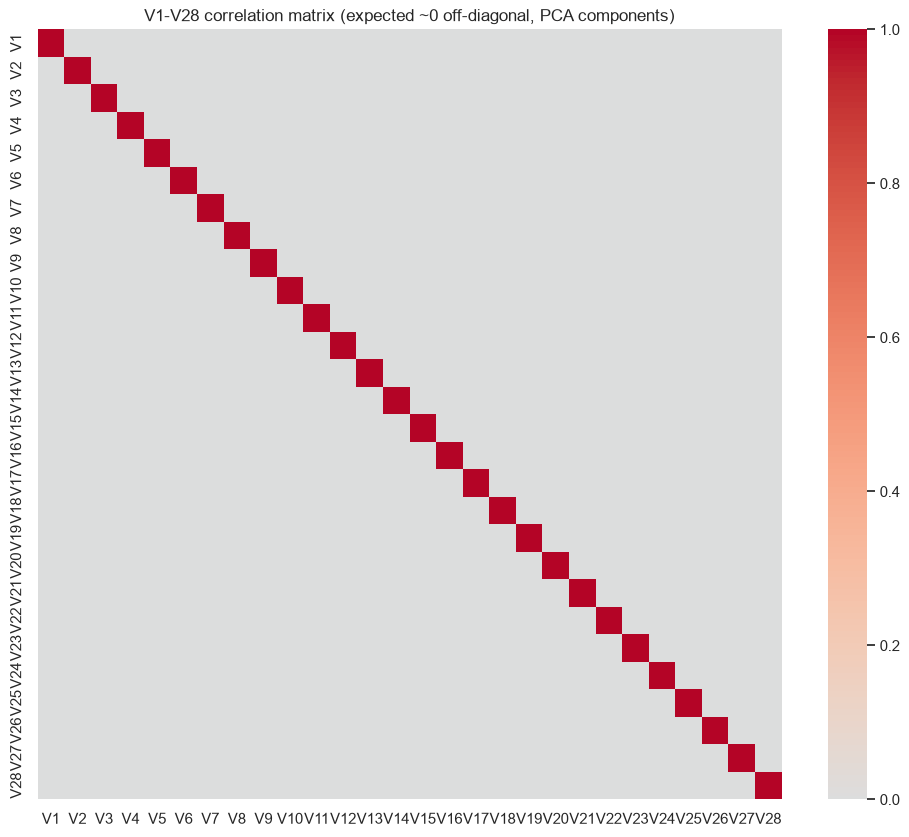

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[v_cols].corr(), cmap="coolwarm", center=0, cbar=True)
plt.title("V1-V28 correlation matrix (expected ~0 off-diagonal, PCA components)")
plt.show()

## Findings

- Class imbalance ratio: 284,315 legit vs. 492 fraud (99.827% vs. 0.173%) — roughly 1 fraud per 578 transactions. Confirms accuracy is not a usable metric; use PR-AUC/recall/precision/F1 on the fraud class.
- Most separating features (by signed corr with `Class`): strongest negative — `V17` (-0.326), `V14` (-0.303), `V12` (-0.261); strongest positive — `V11` (0.155), `V4` (0.133), `V2` (0.091). Good candidates to inspect first during modeling/feature importance, though they remain PCA-anonymized (no real-world meaning).
- Amount: fraud transactions have a lower median Amount (9.25) than legit (22.00) in this dataset — worth checking as a weak signal, not a strong rule.
- Imbalance-handling strategy decision (SMOTE vs. class weights) goes in the Phase 3 modeling notebook/PRD update, not here.